In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.stats import norm

In [22]:
def black_scholes_price(S, K, T, r, sigma, option_type):
    if T <= 0:
        return max(0, S - K) if option_type == 'Call' else max(0, K - S)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2)*T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == 'Call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return price

In [23]:
df=pd.read_csv('Train.csv')
df['OptionTypeEnc'] = df['OptionType'].map({'Call':1, 'Put':0})
df['Volatility'] = df['MarketFearIndex'] / 100
df['BSPrice'] = df.apply(lambda row: black_scholes_price(
    S=row['Spot'],
    K=row['Strike'],
    T=row['TimeToExpiry'],
    r=row['RiskfreeRate']/100,   # Assuming RiskfreeRate is in %
    sigma=row['Volatility'],
    option_type=row['OptionType']), axis=1)

In [24]:
df

,Id,OptionType,Strike,Spot,TimeToExpiry,RiskfreeRate,MarketFearIndex,BuySellRatio,OptionPrice,OptionTypeEnc,Volatility,BSPrice
0,1,Put,120,148.558157,0.944954,2.720659,71.285594,0.487120,2.877919,0,0.712856,22.204019
1,2,Put,80,118.158570,1.723779,4.873176,64.524904,3.444798,11.626476,0,0.645249,13.566793
2,3,Call,90,108.090156,0.411624,5.082002,76.619034,3.750903,27.088208,1,0.766190,30.604756
3,4,Put,90,111.602240,1.951201,5.923971,95.871987,0.319245,4.629991,0,0.958720,33.160656
4,5,Put,150,56.343242,0.878590,3.307863,46.758397,1.031902,90.974035,0,0.467584,89.568640
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,Put,110,93.604069,1.402202,4.373892,6.579450,0.716937,15.969333,0,0.065794,10.212794
9996,9997,Put,150,128.921187,1.327478,3.671062,14.664286,3.716935,28.652963,0,0.146643,17.755282
9997,9998,Put,130,149.113703,0.364902,3.730788,86.857349,3.110948,11.881759,0,0.868573,19.409942
9998,9999,Call,80,134.230541,1.411376,5.937343,17.958159,0.957441,49.882046,1,0.179582,60.676281


In [25]:
features = ['OptionTypeEnc', 'Strike', 'Spot', 'TimeToExpiry', 'RiskfreeRate', 'MarketFearIndex', 'BuySellRatio', 'BSPrice']
target = 'OptionPrice'
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [28]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error


# Model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

# Fit on training data
xgb_model.fit(X_train_pca, y_train)

# Predict
y_pred = xgb_model.predict(X_test_pca)

# Enforce non-negative predictions
y_pred = np.clip(y_pred, 0, None)

# Evaluate
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"XGBoost RMSE (non-negative): {rmse:.4f}")

# Log-transform the target
y_train_log = np.log1p(y_train)  # log(1 + price)

# Fit model
xgb_model.fit(X_train_pca, y_train_log)

# Predict and inverse transform
y_pred_log = xgb_model.predict(X_test_pca)
y_pred = np.expm1(y_pred_log)  # exp(pred) - 1

# Clip at 0
y_pred = np.clip(y_pred, 0, None)

# RMSE
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Log-Transformed RMSE: {rmse:.4f}")


ModuleNotFoundError: No module named 'xgboost'

In [19]:
model = LinearRegression()
model.fit(X_train_pca, y_train)
y_pred = model.predict(X_test_pca)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Test RMSE: {rmse}")

Test RMSE: 3.7172477808585285


In [20]:
df_out=pd.DataFrame({'pred': y_pred, 'Actual': y_test})
df_out

,pred,Actual
6252,4.746422,1.739067
4684,49.357134,46.091919
1731,-3.970529,0.723612
4742,8.424247,8.297960
4521,-3.021298,0.012163
...,...,...
6412,43.964642,41.661251
8285,7.105145,6.314732
7853,19.053740,20.739648
1095,13.301029,12.972902


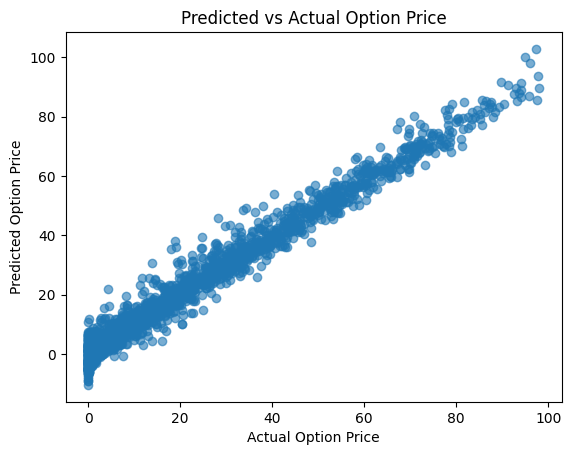

In [10]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel('Actual Option Price')
plt.ylabel('Predicted Option Price')
plt.title('Predicted vs Actual Option Price')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from scipy.interpolate import RegularGridInterpolator
import io

# --- 1. PARAMETERS ---

spot_prices = np.array([100, 100, 100])  # DTC, DFC, DEC
risk_free_rate = 0.05
corr_matrix = np.array([
    [1.0, 0.8, 0.75],
    [0.8, 1.0, 0.85],
    [0.75, 0.85, 1.0]
])
strikes = [50, 75, 100, 125, 150]
maturities = [1, 2, 5]

local_vol_DTC = np.array([
    [0.2205, 0.2240, 0.2248],
    [0.1994, 0.1998, 0.2001],
    [0.1999, 0.2000, 0.2000],
    [0.1998, 0.2000, 0.2000],
    [0.2000, 0.2000, 0.1999]
])
local_vol_DFC = np.array([
    [0.2607, 0.2619, 0.2624],
    [0.2151, 0.2154, 0.2154],
    [0.1999, 0.2000, 0.2000],
    [0.2155, 0.2156, 0.2156],
    [0.2623, 0.2624, 0.2624]
])
local_vol_DEC = np.array([
    [0.2205, 0.2240, 0.2248],
    [0.2120, 0.2125, 0.2122],
    [0.1999, 0.2000, 0.2000],
    [0.1874, 0.1875, 0.1874],
    [0.1745, 0.1746, 0.1750]
])
vol_surfaces = [local_vol_DTC, local_vol_DFC, local_vol_DEC]

def get_interpolators(vol_surface):
    return RegularGridInterpolator((strikes, maturities), vol_surface)

interpolators = [get_interpolators(vol) for vol in vol_surfaces]

# --- 2. MONTE CARLO SIMULATION ---

def simulate_basket_price(knockout, maturity_yrs, strike, option_type, 
                          num_paths=2000, steps_per_year=52):

    dt = 1 / steps_per_year
    steps = int(maturity_yrs * steps_per_year)
    dim = len(spot_prices)

    chol = np.linalg.cholesky(corr_matrix)
    prices = np.full((num_paths, dim), spot_prices, dtype=np.float64)

    basket_prices = np.zeros((num_paths, steps + 1))
    basket_prices[:, 0] = np.mean(prices, axis=1)

    for t in range(1, steps + 1):
        Z = np.random.normal(size=(num_paths, dim))
        correlated_Z = Z @ chol.T

        for i in range(dim):
            S = prices[:, i]
            t_years = t * dt
            vol = interpolators[i]((np.clip(S, 50, 150), np.full(S.shape, maturity_yrs)))
            dS = risk_free_rate * S * dt + vol * S * np.sqrt(dt) * correlated_Z[:, i]
            prices[:, i] += dS

        basket_prices[:, t] = np.mean(prices, axis=1)

    knocked_out = np.any(basket_prices >= knockout, axis=1)

    final_prices = basket_prices[:, -1]
    if option_type.lower() == 'call':
        payoffs = np.maximum(final_prices - strike, 0)
    else:
        payoffs = np.maximum(strike - final_prices, 0)

    payoffs[knocked_out] = 0
    discounted = np.exp(-risk_free_rate * maturity_yrs) * payoffs
    return np.mean(discounted)

# --- 3. EMBEDDED INPUT CSV ---

input_csv = """
Id,Asset,KnockOut,Maturity,Strike,Type
1,Basket,150,2y,50,Call
2,Basket,175,2y,50,Call
3,Basket,200,2y,50,Call
4,Basket,150,5y,50,Call
5,Basket,175,5y,50,Call
6,Basket,200,5y,50,Call
7,Basket,150,2y,100,Call
8,Basket,175,2y,100,Call
9,Basket,200,2y,100,Call
10,Basket,150,5y,100,Call
11,Basket,175,5y,100,Call
12,Basket,200,5y,100,Call
13,Basket,150,2y,125,Call
14,Basket,175,2y,125,Call
15,Basket,200,2y,125,Call
16,Basket,150,5y,125,Call
17,Basket,175,5y,125,Call
18,Basket,200,5y,125,Call
19,Basket,150,2y,75,Put
20,Basket,175,2y,75,Put
21,Basket,200,2y,75,Put
22,Basket,150,5y,75,Put
23,Basket,175,5y,75,Put
24,Basket,200,5y,75,Put
25,Basket,150,2y,100,Put
26,Basket,175,2y,100,Put
27,Basket,200,2y,100,Put
28,Basket,150,5y,100,Put
29,Basket,175,5y,100,Put
30,Basket,200,5y,100,Put
31,Basket,150,2y,125,Put
32,Basket,175,2y,125,Put
33,Basket,200,2y,125,Put
34,Basket,150,5y,125,Put
35,Basket,175,5y,125,Put
36,Basket,200,5y,125,Put
"""

input_df = pd.read_csv(io.StringIO(input_csv.strip()))

# --- 4. PROCESSING ---

output = []

for _, row in input_df.iterrows():
    id_, ko, maturity_str, strike, opt_type = row['Id'], row['KnockOut'], row['Maturity'], row['Strike'], row['Type']
    maturity = int(maturity_str.strip('y'))
    price = simulate_basket_price(knockout=ko, maturity_yrs=maturity, strike=strike, option_type=opt_type)
    output.append((id_, round(price, 2)))

output_df = pd.DataFrame(output, columns=["Id", "Price"])
print(output_df.to_csv(index=False))


Id,Price
1,39.05
2,48.56
3,53.41
4,17.77
5,29.43
6,38.47
7,7.38
8,11.34
9,14.24
10,3.33
11,7.23
12,12.63
13,0.95
14,3.2
15,6.1
16,0.49
17,2.08
18,5.6
19,0.74
20,0.73
21,0.68
22,1.58
23,1.51
24,1.61
25,5.82
26,5.87
27,5.81
28,5.88
29,6.12
30,5.91
31,19.08
32,19.38
33,19.43
34,14.98
35,15.48
36,13.61

